Kelompok 17

Anggota:
1.   Abdulhadi Muntashir
2.   Naufal Pancar Nugraha
3.   M Hafid Ramadhan


In [23]:
# =========================
# TAHAP 1: Data Aggregation & Preprocessing
# 0. Deteksi dataset dari folder Datasets
# =========================
from pathlib import Path

CSV_PATH = None
EXPECTED_CSV = "tokopedia_product_reviews_2025.csv"
DATASET_DIR = Path("Datasets")

def pick_csv(candidates):
    if not candidates:
        return None
    # Prioritaskan nama file yang sesuai instruksi tugas
    for c in candidates:
        if c.name.lower() == EXPECTED_CSV.lower():
            return str(c)
    return str(candidates[0])

if not DATASET_DIR.exists():
    raise FileNotFoundError(
        "Folder 'Datasets' tidak ditemukan. Pastikan struktur project berisi folder Datasets/."
    )

csv_candidates = sorted(DATASET_DIR.glob("*.csv"))
CSV_PATH = pick_csv(csv_candidates)

if CSV_PATH is None:
    raise FileNotFoundError(
        "Tidak ada file CSV di folder Datasets/.\n"
        "Pastikan file dataset sudah tersedia, misalnya: Datasets/tokopedia_product_reviews_2025.csv"
    )

print(f"Dataset yang akan dipakai: {CSV_PATH}")
print("Daftar CSV terdeteksi:", [p.name for p in csv_candidates])

Dataset yang akan dipakai: Datasets\tokopedia_product_reviews_2025.csv
Daftar CSV terdeteksi: ['dummy_model_predictions.csv', 'tokopedia_product_reviews_2025.csv']


In [24]:
# =========================
# 1. Import library
# =========================
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

RANDOM_STATE = 42

In [25]:

# =========================
# 2. Validasi path dataset
# =========================
dataset_path = Path(CSV_PATH)

if not dataset_path.exists():
    isi_datasets = sorted([p.name for p in Path("Datasets").glob("*")]) if Path("Datasets").exists() else "folder tidak ditemukan"
    print("Isi folder Datasets saat ini:", isi_datasets)
    raise FileNotFoundError(
        f"File CSV tidak ditemukan di path: {CSV_PATH}\n"
        "Pastikan file CSV tersedia di folder Datasets/."
    )

print("Dataset ditemukan dan siap dibaca dari:", dataset_path.resolve())


Dataset ditemukan dan siap dibaca dari: G:\Project\VINIX7\Datasets\tokopedia_product_reviews_2025.csv


In [26]:
# ========================================================
# 3. LOAD DATASET
# ========================================================
df = pd.read_csv(CSV_PATH)
print(f"Dataset berhasil dimuat dari: {CSV_PATH}")
print(f"Jumlah baris: {len(df):,} | Jumlah kolom: {df.shape[1]}")

# Penanganan missing values dasar agar fungsi teks dan numerik tidak error
df['review_text'] = df['review_text'].fillna('')
df['sentiment_label'] = df['sentiment_label'].fillna('neutral')
df['product_price'] = pd.to_numeric(df['product_price'], errors='coerce')
df['sold_count'] = pd.to_numeric(df['sold_count'], errors='coerce')

# Membuat kolom indikator untuk agregasi
df['review_length'] = df['review_text'].str.len()
df['is_positive'] = df['sentiment_label'].apply(lambda x: 1 if str(x).lower() == 'positive' else 0)

# ========================================================
# 4. AGREGASI DATA (GROUP BY)
# ========================================================
# Sesuai instruksi: mengelompokkan berdasarkan product_name
# sold_count pada level ulasan cenderung berulang per produk, sehingga dipakai 'max'
# untuk merepresentasikan total terjual per produk tanpa double counting.
df_product = df.groupby('product_name').agg({
    'product_price': 'mean',       # Rata-rata harga
    'sold_count': 'max',           # Total produk terjual per produk (anti double count)
    'is_positive': 'mean',         # Persentase ulasan positif (0.0 - 1.0)
    'review_length': 'mean'        # Rata-rata panjang karakter ulasan
}).reset_index()

# Drop missing values hasil agregasi (jika ada produk tanpa harga/penjualan valid)
df_product = df_product.dropna()

# ========================================================
# 5. PENSKALAAN DATA (STANDARD SCALER)
# ========================================================
scaler = StandardScaler()
features_to_scale = ['product_price', 'sold_count', 'is_positive', 'review_length']

# Copy dataframe agar data asli (sebelum scaling) tetap bisa dilihat
df_product_scaled = df_product.copy()

# Menerapkan StandardScaler
df_product_scaled[features_to_scale] = scaler.fit_transform(df_product_scaled[features_to_scale])

# Menampilkan hasil
print("--- Dataframe Agregasi Produk (Sebelum Scaling) ---")
print(df_product.head())

print("\n--- Dataframe Setelah StandardScaler ---")
print(df_product_scaled.head())

Dataset berhasil dimuat dari: Datasets\tokopedia_product_reviews_2025.csv
Jumlah baris: 65,543 | Jumlah kolom: 13
--- Dataframe Agregasi Produk (Sebelum Scaling) ---
                                                                                                          product_name  \
0            ( ISI 5 GRATIS 1 ) Dextone Lem Kaca Silicone Sealant Tabung Netral 300ml lem  sealant pvc lem  wall panel   
1                                                   (BUNDLING 2 BOX) Telur Ayam Kampung Asli- Telur Mengandung Omega 3   
2                                                  (NEW) AIR PURIFIER SHARP 50 M2 - KIL60Y - PLASMACLUSTER ANTI CORONA   
3  (PAKET 3 BOTOL) SATYA Jus Bawang Putih Tunggal Jahe Merah Madu Hutan Cuka Apel Lemon sudah BPOM TR Natural dan Aman   
4                                                       (RESMI) Samsung Galaxy Tab S10 Lite 6/128GB WIFI Gray Coralred   

   product_price  sold_count  is_positive  review_length  
0       240000.0         100         1.00 

Explained Variance Ratio PC1: 27.69%
Explained Variance Ratio PC2: 26.46%
Total Informasi (Varians) yang Dipertahankan: 54.15%

--- Dataframe Hasil PCA (2 Dimensi) ---
        PC1       PC2  \
0 -0.128887  0.357602   
1 -1.010579  0.102039   
2  0.614881  1.182693   
3 -1.142509  1.286451   
4 -0.123324  1.503537   

                                                                                                          product_name  
0            ( ISI 5 GRATIS 1 ) Dextone Lem Kaca Silicone Sealant Tabung Netral 300ml lem  sealant pvc lem  wall panel  
1                                                   (BUNDLING 2 BOX) Telur Ayam Kampung Asli- Telur Mengandung Omega 3  
2                                                  (NEW) AIR PURIFIER SHARP 50 M2 - KIL60Y - PLASMACLUSTER ANTI CORONA  
3  (PAKET 3 BOTOL) SATYA Jus Bawang Putih Tunggal Jahe Merah Madu Hutan Cuka Apel Lemon sudah BPOM TR Natural dan Aman  
4                                                       (RESMI) Samsung Gala

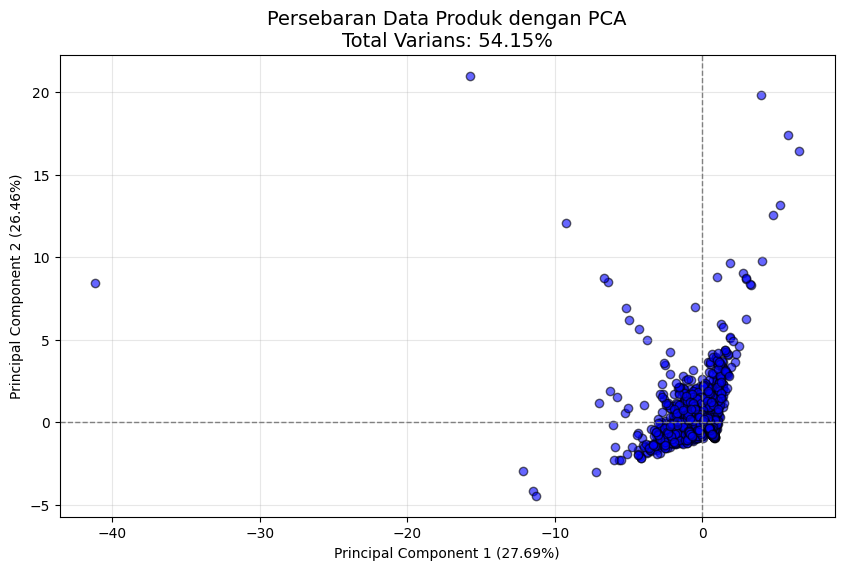

In [27]:
# ========================================================
# TAHAP 2: DIMENSIONALITY REDUCTION (PCA)
# ========================================================
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=42)
pca_features = pca.fit_transform(df_product_scaled[features_to_scale])

df_pca = pd.DataFrame(data=pca_features, columns=['PC1', 'PC2'])
df_pca['product_name'] = df_product['product_name'].values

explained_variance = pca.explained_variance_ratio_
total_variance_retained = sum(explained_variance) * 100

print(f"Explained Variance Ratio PC1: {explained_variance[0]*100:.2f}%")
print(f"Explained Variance Ratio PC2: {explained_variance[1]*100:.2f}%")
print(f"Total Informasi (Varians) yang Dipertahankan: {total_variance_retained:.2f}%\n")
print("--- Dataframe Hasil PCA (2 Dimensi) ---")
print(df_pca.head())

plt.figure(figsize=(10, 6))
plt.scatter(df_pca['PC1'], df_pca['PC2'], alpha=0.6, color='b', edgecolor='k')
plt.axhline(0, color='grey', linestyle='--', linewidth=1)
plt.axvline(0, color='grey', linestyle='--', linewidth=1)
plt.title(f'Persebaran Data Produk dengan PCA\nTotal Varians: {total_variance_retained:.2f}%', fontsize=14)
plt.xlabel(f'Principal Component 1 ({explained_variance[0]*100:.2f}%)')
plt.ylabel(f'Principal Component 2 ({explained_variance[1]*100:.2f}%)')
plt.grid(True, alpha=0.3)
plt.show()

## Interpretasi 1 - Reduksi Dimensi dan Varians
1. Rasio varians yang dipertahankan:
PCA 2 komponen mempertahankan sekitar 54 persen informasi total dari data 4 dimensi.

2. Apakah 2 dimensi cukup mewakili data:
Dua komponen utama sudah cukup untuk visualisasi segmentasi awal, tetapi masih ada information loss yang berarti. Karena itu, hasil PCA ini lebih tepat dipakai untuk eksplorasi pola dan clustering awal, bukan sebagai pengganti penuh fitur asli.

3. Persebaran data:
Persebaran titik pada bidang PC1 dan PC2 menunjukkan adanya pemisahan kelompok utama dan beberapa titik ekstrem. Ini mengindikasikan struktur segmentasi ada, sekaligus memberi sinyal kandidat outlier yang perlu diuji lebih lanjut pada tahap DBSCAN.

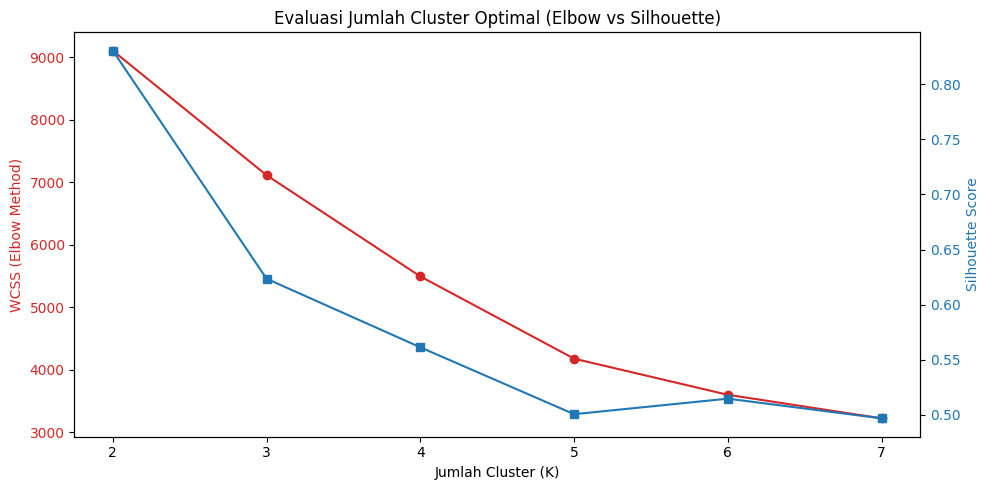


K Optimal terpilih berdasarkan Silhouette Score tertinggi: 2



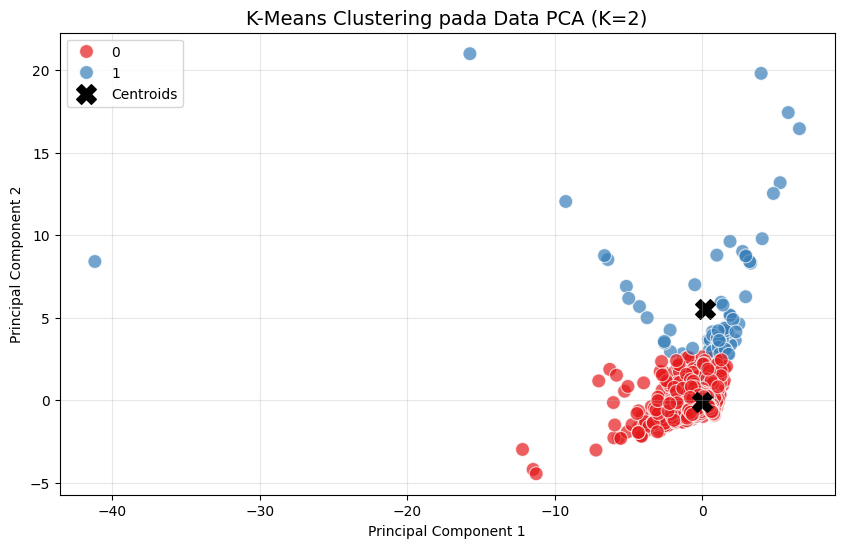

--- Profiling Karakteristik Statistik Masing-Masing Cluster ---
         jumlah_produk  product_price  sold_count  is_positive  review_length
Cluster                                                                      
0                 5334      701818.58     1095.88         0.98          69.85
1                   84    24902995.70    12086.92         1.00         178.69


In [28]:
# ========================================================
# TAHAP 3: EKSPERIMEN K-MEANS CLUSTERING
# ========================================================
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Pastikan variabel 'pca_features' dan 'df_pca' dari Tahap 2 sudah tersedia

# 1. Mencari K optimal dengan Elbow Method & Silhouette Score
wcss = []
silhouette_scores = []
K_range = range(2, 8) # Mencoba jumlah klaster dari 2 hingga 7

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(pca_features)
    wcss.append(kmeans.inertia_) # Untuk Elbow Method
    silhouette_scores.append(silhouette_score(pca_features, labels)) # Untuk Silhouette Score

# --- Visualisasi Elbow & Silhouette Score ---
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:red'
ax1.set_xlabel('Jumlah Cluster (K)')
ax1.set_ylabel('WCSS (Elbow Method)', color=color)
ax1.plot(K_range, wcss, marker='o', color=color, label='WCSS')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(K_range, silhouette_scores, marker='s', color=color, label='Silhouette Score')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Evaluasi Jumlah Cluster Optimal (Elbow vs Silhouette)')
fig.tight_layout()
plt.show()

# 2. Melatih Model dengan K Optimal
# Secara otomatis memilih K dengan Silhouette Score tertinggi
best_k = K_range[np.argmax(silhouette_scores)]
print(f"\nK Optimal terpilih berdasarkan Silhouette Score tertinggi: {best_k}\n")

# Latih K-Means final
kmeans_final = KMeans(n_clusters=best_k, random_state=42)
cluster_labels = kmeans_final.fit_predict(pca_features)

# Memasukkan label cluster ke dalam dataframe PCA dan dataframe Asli
df_pca['Cluster'] = cluster_labels
df_product['Cluster'] = cluster_labels # Dimasukkan ke df asli untuk interpretasi/profiling

# 3. Scatter Plot 2D (PC1 vs PC2) dengan warna cluster
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', palette='Set1', data=df_pca, s=100, alpha=0.7)

# Menambahkan Centroid (Titik Pusat Cluster) pada plot
centroids = kmeans_final.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], c='black', s=200, marker='X', label='Centroids')

plt.title(f'K-Means Clustering pada Data PCA (K={best_k})', fontsize=14)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 4. Profiling Cluster (Statistik dari Data Asli sebelum discaling)
print("--- Profiling Karakteristik Statistik Masing-Masing Cluster ---")
cluster_profile = df_product.groupby('Cluster').agg({
    'product_name': 'count',
    'product_price': 'mean',
    'sold_count': 'mean',
    'is_positive': 'mean',
    'review_length': 'mean'
}).rename(columns={'product_name': 'jumlah_produk'}).round(2)

print(cluster_profile)

## Interpretasi 2 - Profiling Cluster
1. Penentuan K Optimal:
K optimal terpilih adalah 2 (berdasarkan Silhouette Score tertinggi), sehingga segmentasi produk pada run terbaru terbagi menjadi dua kelompok utama yang stabil.

2. Profiling kuantitatif tiap cluster (run terbaru):
- Cluster 0 (5.334 produk): rata-rata harga 701.818,58; rata-rata sold_count 1.095,88; persentase positif 0,98; rata-rata review_length 69,85.
- Cluster 1 (84 produk): rata-rata harga 24.902.995,70; rata-rata sold_count 12.086,92; persentase positif 1,00; rata-rata review_length 178,69.

3. Implikasi bisnis dari profil cluster:
- Cluster 0 dapat diposisikan sebagai segmen mass-market dengan skala produk besar, sentimen tetap tinggi, dan karakter ulasan relatif ringkas.
- Cluster 1 merupakan segmen premium bernilai tinggi (harga dan volume terjual jauh di atas rata-rata) dengan ulasan lebih panjang; perlu quality monitoring yang lebih ketat walaupun sentimen agregat tinggi.

Catatan metodologis:
Pada Tahap 1, agregasi sold_count menggunakan max per produk untuk menghindari double counting pada data level ulasan yang berulang.

=== Ringkasan Eksperimen Parameter DBSCAN ===
 eps  min_samples  n_clusters  n_noise  noise_ratio  silhouette_non_noise
 0.5            5           2       52     0.009598              0.883515
 0.7            5           2       42     0.007752              0.882096
 0.7            3           2       34     0.006275              0.880353
 0.9            5           2       32     0.005906              0.879841
 0.9            3           3       26     0.004799              0.850419
 0.3           10           3      147     0.027132              0.706319
 0.3            5           4       84     0.015504              0.704718
 0.5            3           5       41     0.007567              0.620052
 0.3            3           7       60     0.011074              0.603227
 0.9           10           1       44     0.008121                   NaN
 0.7           10           1       52     0.009598                   NaN
 0.5           10           1       77     0.014212               

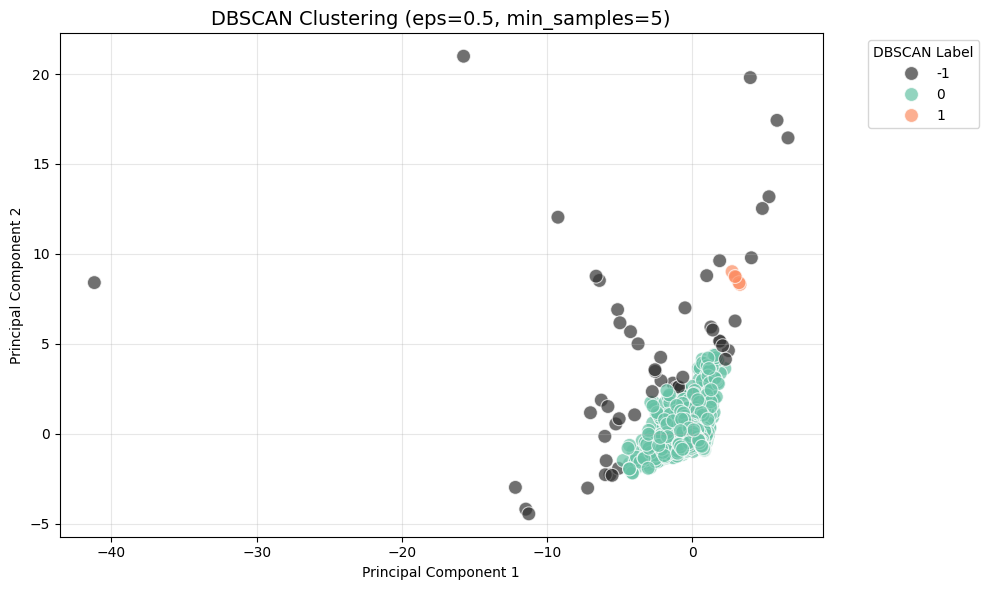

--- Sampel Data Produk Anomali (Label -1) ---
                                                              product_name  \
161  AQUA JAPAN AQRD275 - KULKAS 2 PINTU INVERTER AQUA SANYO AQR D275 KACA   
569             Baygon Max Aerosol Floral Fantasy 500ml 2x Free Mama Lemon   
618        BioTechUSA - 100% CREATINE MONOHYDRATE 300 Gram ,optimum energy   
636      Blue Diamond Chalk - 2 Piece Billiard Chalk - Kapur Biliar - Biru   
972                                    Celana Waldos Running Black Premium   

     product_price  sold_count  review_length  
161      3799000.0          18         260.50  
569        76330.0          30         324.50  
618       489999.0          40         781.00  
636       150000.0        2000        1076.15  
972       164900.0         100         549.50  


In [29]:
# ========================================================
# TAHAP 4: EKSPERIMEN DBSCAN & DETEKSI ANOMALI
# ========================================================
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Eksperimen parameter DBSCAN (eps, min_samples)
eps_candidates = [0.3, 0.5, 0.7, 0.9]
min_samples_candidates = [3, 5, 10]

dbscan_results = []

for eps in eps_candidates:
    for min_samples in min_samples_candidates:
        model = DBSCAN(eps=eps, min_samples=min_samples)
        labels = model.fit_predict(pca_features)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = int((labels == -1).sum())
        noise_ratio = n_noise / len(labels)

        # Silhouette dihitung hanya jika ada >=2 cluster non-noise
        non_noise_mask = labels != -1
        unique_non_noise = set(labels[non_noise_mask])
        sil = np.nan
        if len(unique_non_noise) >= 2 and non_noise_mask.sum() > len(unique_non_noise):
            sil = silhouette_score(pca_features[non_noise_mask], labels[non_noise_mask])

        dbscan_results.append({
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'noise_ratio': noise_ratio,
            'silhouette_non_noise': sil,
        })

dbscan_eval = pd.DataFrame(dbscan_results)

# Prioritaskan silhouette tertinggi (jika tersedia), lalu noise ratio terendah
if dbscan_eval['silhouette_non_noise'].notna().any():
    dbscan_eval_sorted = dbscan_eval.sort_values(
        by=['silhouette_non_noise', 'noise_ratio'],
        ascending=[False, True]
    )
else:
    dbscan_eval_sorted = dbscan_eval.sort_values(by='noise_ratio', ascending=True)

best_dbscan = dbscan_eval_sorted.iloc[0]
eps_value = float(best_dbscan['eps'])
min_samples_value = int(best_dbscan['min_samples'])

print("=== Ringkasan Eksperimen Parameter DBSCAN ===")
print(dbscan_eval_sorted.to_string(index=False))
print("\nParameter terbaik terpilih:")
print(f"eps={eps_value}, min_samples={min_samples_value}")

# 2. Melatih model DBSCAN final
dbscan = DBSCAN(eps=eps_value, min_samples=min_samples_value)
dbscan_labels = dbscan.fit_predict(pca_features)

# Memasukkan label ke dataframe
df_pca['Cluster_DBSCAN'] = dbscan_labels
df_product['Cluster_DBSCAN'] = dbscan_labels

# Menghitung jumlah cluster yang terbentuk dan jumlah anomali (noise)
n_clusters_ = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_ = int((dbscan_labels == -1).sum())

print(f"\nBerdasarkan eps={eps_value} dan min_samples={min_samples_value}:")
print(f"Jumlah Cluster (selain noise): {n_clusters_}")
print(f"Jumlah Titik Anomali (Noise / Label -1): {n_noise_}\n")

# 3. Scatter Plot DBSCAN
plt.figure(figsize=(10, 6))

# Bangun palet warna yang stabil untuk setiap label
unique_labels = sorted(df_pca['Cluster_DBSCAN'].unique())
non_noise_labels = [lbl for lbl in unique_labels if lbl != -1]
base_palette = sns.color_palette("Set2", max(len(non_noise_labels), 1))
color_map = {-1: '#333333'}
for idx, lbl in enumerate(non_noise_labels):
    color_map[lbl] = base_palette[idx]

sns.scatterplot(
    x='PC1', y='PC2',
    hue='Cluster_DBSCAN',
    palette=color_map,
    data=df_pca,
    s=100,
    alpha=0.7
)

plt.title(f'DBSCAN Clustering (eps={eps_value}, min_samples={min_samples_value})', fontsize=14)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='DBSCAN Label', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Mengintip Karakteristik Data Anomali (Opsional untuk membantu Interpretasi) ---
if n_noise_ > 0:
    print("--- Sampel Data Produk Anomali (Label -1) ---")
    anomalies = df_product[df_product['Cluster_DBSCAN'] == -1]
    print(anomalies[['product_name', 'product_price', 'sold_count', 'review_length']].head())

## Interpretasi 3 - DBSCAN & Deteksi Anomali
1. Perbedaan Utama DBSCAN vs K-Means:
K-Means memaksa semua titik masuk ke cluster tertentu, sedangkan DBSCAN dapat memberi label noise (-1) pada titik yang tidak berada pada area densitas tinggi. Ini membuat DBSCAN lebih cocok untuk mendeteksi outlier produk.

2. Eksperimen Parameter:
Model DBSCAN dievaluasi pada beberapa kombinasi `eps` dan `min_samples`, lalu dipilih parameter terbaik secara kuantitatif menggunakan prioritas:
- silhouette score non-noise tertinggi (jika valid),
- noise ratio terendah sebagai tie-breaker.

3. Dampak Bisnis:
Produk berlabel noise dapat diperlakukan sebagai kandidat audit karena berpotensi memiliki pola ekstrem (harga, volume, atau review behavior) yang tidak mewakili kelompok utama.

In [30]:
# ========================================================
# TAHAP 5: ASSOCIATION RULES (APRIORI) - ORIGINAL vs BALANCED
# ========================================================
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# 1. Load Data Mentah (Level Ulasan)
df_raw = pd.read_csv(CSV_PATH)
print(f"Data mentah untuk Apriori dimuat dari: {CSV_PATH}")

# Membersihkan missing values pada kolom target
df_raw['product_category'] = df_raw['product_category'].fillna('Unknown_Category')
df_raw['product_variant'] = df_raw['product_variant'].fillna('Unknown_Variant')
df_raw['sentiment_label'] = df_raw['sentiment_label'].fillna('neutral')

# Memfilter hanya sentimen positif dan negatif untuk asosiasi yang tegas
df_filtered = df_raw[df_raw['sentiment_label'].isin(['positive', 'negative'])].copy()
print("Distribusi sentimen data asli:")
print(df_filtered['sentiment_label'].value_counts(), "\n")

def mine_sentiment_rules(df_input, min_conf=0.5, support_candidates=(0.02, 0.01, 0.005)):
    """Menambang aturan asosiasi dengan fallback min_support agar tidak kosong."""
    work = df_input.copy()
    work['item_category'] = "Kategori_" + work['product_category'].astype(str)
    work['item_variant'] = "Varian_" + work['product_variant'].astype(str)
    work['item_sentiment'] = "Sentimen_" + work['sentiment_label'].astype(str)

    transactions = work[['item_category', 'item_variant', 'item_sentiment']].values.tolist()
    te = TransactionEncoder()
    te_ary = te.fit(transactions).transform(transactions)
    df_trans = pd.DataFrame(te_ary, columns=te.columns_)

    selected_support = None
    selected_itemsets = None
    selected_rules = None

    for ms in support_candidates:
        itemsets = apriori(df_trans, min_support=ms, use_colnames=True)
        if itemsets.empty:
            continue

        candidate_rules = association_rules(itemsets, metric="confidence", min_threshold=min_conf)
        if candidate_rules.empty:
            continue

        selected_support = ms
        selected_itemsets = itemsets
        selected_rules = candidate_rules
        break

    if selected_rules is None:
        return None, None, None, None

    def is_pure_sentiment_consequent(itemset):
        if len(itemset) != 1:
            return False
        only_item = next(iter(itemset))
        return only_item.startswith("Sentimen_")

    rules_sent = selected_rules[selected_rules['consequents'].apply(is_pure_sentiment_consequent)].copy()
    rules_sent = rules_sent.sort_values(by='lift', ascending=False)

    return selected_support, selected_itemsets, selected_rules, rules_sent

# 2A. Mining pada data asli (mewakili distribusi pasar aktual)
support_original, frequent_itemsets_original, rules_original_all, rules_sentiment_original = mine_sentiment_rules(df_filtered)

if rules_sentiment_original is None or rules_sentiment_original.empty:
    print("[ORIGINAL] Tidak ditemukan rule sentimen murni dengan konfigurasi support fallback.")
else:
    print(f"[ORIGINAL] min_support terpilih: {support_original}")
    print("--- Top 10 Rules Data Asli (Consequent Sentimen Murni) ---")
    print(rules_sentiment_original[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10), "\n")

# 2B. Mining pada data balanced (pattern discovery kelas minoritas)
df_pos = df_filtered[df_filtered['sentiment_label'] == 'positive']
df_neg = df_filtered[df_filtered['sentiment_label'] == 'negative']

if len(df_neg) > 0 and len(df_pos) >= len(df_neg):
    df_pos_sampled = df_pos.sample(n=len(df_neg), random_state=42)
    df_balanced = pd.concat([df_pos_sampled, df_neg], ignore_index=True)
else:
    # Fallback aman jika distribusi tidak memenuhi syarat undersampling 1:1
    df_balanced = df_filtered.copy()

print("Distribusi data setelah skema balancing:")
print(df_balanced['sentiment_label'].value_counts(), "\n")

support_balanced, frequent_itemsets_balanced, rules_balanced_all, rules_sentiment_balanced = mine_sentiment_rules(df_balanced)

if rules_sentiment_balanced is None or rules_sentiment_balanced.empty:
    print("[BALANCED] Tidak ditemukan rule sentimen murni dengan konfigurasi support fallback.")
else:
    print(f"[BALANCED] min_support terpilih: {support_balanced}")
    print("--- Top 10 Rules Data Balanced (Consequent Sentimen Murni) ---")
    print(rules_sentiment_balanced[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10), "\n")

# Kompatibilitas dengan cell lanjutan yang sudah ada
rules_sentiment = rules_sentiment_balanced.copy() if rules_sentiment_balanced is not None else pd.DataFrame()
rules = rules_balanced_all.copy() if rules_balanced_all is not None else pd.DataFrame()
frequent_itemsets = frequent_itemsets_balanced.copy() if frequent_itemsets_balanced is not None else pd.DataFrame()

Data mentah untuk Apriori dimuat dari: Datasets\tokopedia_product_reviews_2025.csv
Distribusi sentimen data asli:
sentiment_label
positive    63943
negative      798
Name: count, dtype: int64 

[ORIGINAL] min_support terpilih: 0.02
--- Top 10 Rules Data Asli (Consequent Sentimen Murni) ---
                                              antecedents  \
17           (Varian_Unknown_Variant, Kategori_Kesehatan)   
3                                    (Kategori_Kesehatan)   
14          (Varian_Unknown_Variant, Kategori_Elektronik)   
0                                   (Kategori_Elektronik)   
2                           (Kategori_Handphone & Tablet)   
25         (Varian_Unknown_Variant, Kategori_Pertukangan)   
16  (Kategori_Handphone & Tablet, Varian_Unknown_Variant)   
11                               (Varian_Unknown_Variant)   
8                                  (Kategori_Pertukangan)   
10                                       (Varian_Default)   

            consequents   support  co

Interpretasi Tahap 5 - Aturan Asosiasi (Original vs Balanced)
1. Hasil pada data asli (distribusi pasar aktual):
Data asli sangat imbalance (positive 63.943 vs negative 798). Pada kondisi ini, rule paling kuat didominasi consequent Sentimen_positive dengan confidence sangat tinggi (~0,99) dan lift mendekati 1. Artinya, rule dari data asli menangkap baseline pasar yang memang mayoritas positif, tetapi kurang tajam untuk menemukan pola kelas negatif.

2. Hasil pada data balanced (pattern discovery minoritas):
Setelah balancing 1:1 (positive 798, negative 798), pola kelas negatif menjadi lebih terlihat. Contoh rule penting:
- Kategori_Olahraga -> Sentimen_negative (support 0,1736; confidence 0,5919; lift 1,1838)
- Kategori_Makanan & Minuman -> Sentimen_negative (support 0,1648; confidence 0,5434; lift 1,0868)
Sementara rule positif kuat juga muncul, misalnya Kategori_Kesehatan + Varian_Unknown_Variant -> Sentimen_positive (lift 1,5102).

3. Implikasi penggunaan metrik:
- Rule data asli dipakai untuk membaca real market prevalence.
- Rule data balanced dipakai untuk eksplorasi pola risiko pada kelas minoritas.
Keputusan bisnis sebaiknya menggunakan keduanya secara komplementer agar tidak bias ke salah satu distribusi data.

In [31]:
from IPython.display import display
import pandas as pd
import numpy as np

print("=== PROFILING CLUSTER K-MEANS ===")
display(cluster_profile)

cluster_profile_labeled = cluster_profile.copy()
price_mid = cluster_profile['product_price'].median()
sold_mid = cluster_profile['sold_count'].median()
pos_mid = cluster_profile['is_positive'].median()
review_mid = cluster_profile['review_length'].median()
size_mid = cluster_profile['jumlah_produk'].median()

def beri_nama_cluster(row):
    harga_tinggi = row['product_price'] >= price_mid
    terjual_tinggi = row['sold_count'] >= sold_mid
    sentimen_tinggi = row['is_positive'] >= pos_mid
    ulasan_panjang = row['review_length'] >= review_mid
    ukuran_besar = row['jumlah_produk'] >= size_mid
    if harga_tinggi and terjual_tinggi and ulasan_panjang:
        return "Produk Ultra-Premium Sensitif Evaluasi"
    if ukuran_besar and (not harga_tinggi) and sentimen_tinggi:
        return "Produk Reguler Arus Utama"
    if (not sentimen_tinggi) and ulasan_panjang:
        return "Produk Rentan Komplain"
    return "Produk Standar Perlu Monitoring"

cluster_profile_labeled['nama_profil_cluster'] = cluster_profile_labeled.apply(beri_nama_cluster, axis=1)
print("=== PROFIL CLUSTER DENGAN PENAMAAN BISNIS ===")
display(cluster_profile_labeled)

def itemset_to_text(itemset):
    return ", ".join(list(itemset))

def build_readable_rules(df_rules, label):
    if df_rules is None or df_rules.empty:
        print(f"=== {label}: TIDAK ADA RULE ===")
        return pd.DataFrame(), pd.DataFrame()

    readable = df_rules.copy()
    readable['antecedents_text'] = readable['antecedents'].apply(itemset_to_text)
    readable['consequents_text'] = readable['consequents'].apply(itemset_to_text)

    rules_neg = readable[
        readable['consequents_text'].str.contains("Sentimen_negative", case=False, na=False)
    ].sort_values(by='lift', ascending=False)

    rules_pos = readable[
        readable['consequents_text'].str.contains("Sentimen_positive", case=False, na=False)
    ].sort_values(by='lift', ascending=False)

    print(f"=== TOP RULES NEGATIF ({label}) ===")
    display(rules_neg[['antecedents_text', 'consequents_text', 'support', 'confidence', 'lift']].head(10))

    print(f"=== TOP RULES POSITIF ({label}) ===")
    display(rules_pos[['antecedents_text', 'consequents_text', 'support', 'confidence', 'lift']].head(10))

    return rules_neg, rules_pos

rules_negatif_original, rules_positif_original = build_readable_rules(rules_sentiment_original, "DATA ASLI")
rules_negatif, rules_positif = build_readable_rules(rules_sentiment_balanced, "DATA BALANCED")

=== PROFILING CLUSTER K-MEANS ===


,jumlah_produk,product_price,sold_count,is_positive,review_length
Cluster,,,,,
0,5334,701818.58,1095.88,0.98,69.85
1,84,24902995.70,12086.92,1.00,178.69


=== PROFIL CLUSTER DENGAN PENAMAAN BISNIS ===


,jumlah_produk,product_price,sold_count,is_positive,review_length,nama_profil_cluster
Cluster,,,,,,
0,5334,701818.58,1095.88,0.98,69.85,Produk Standar Perlu Monitoring
1,84,24902995.70,12086.92,1.00,178.69,Produk Ultra-Premium Sensitif Evaluasi


=== TOP RULES NEGATIF (DATA ASLI) ===


...

,antecedents_text,consequents_text,support,confidence,lift
17,"Varian_Unknown_Variant, Kategori_Kesehatan",Sentimen_positive,0.092368,0.996003,1.008433
3,Kategori_Kesehatan,Sentimen_positive,0.136791,0.995616,1.008041
14,"Varian_Unknown_Variant, Kategori_Elektronik",Sentimen_positive,0.050262,0.995411,1.007834
0,Kategori_Elektronik,Sentimen_positive,0.064210,0.994260,1.006668
2,Kategori_Handphone & Tablet,Sentimen_positive,0.112927,0.991591,1.003966
25,"Varian_Unknown_Variant, Kategori_Pertukangan",Sentimen_positive,0.123909,0.990126,1.002483
16,"Kategori_Handphone & Tablet, Varian_Unknown_Variant",Sentimen_positive,0.042971,0.989331,1.001678
11,Varian_Unknown_Variant,Sentimen_positive,0.585564,0.989120,1.001464
8,Kategori_Pertukangan,Sentimen_positive,0.173306,0.988285,1.000619
10,Varian_Default,Sentimen_positive,0.026181,0.987187,0.999507


=== TOP RULES NEGATIF (DATA BALANCED) ===


,antecedents_text,consequents_text,support,confidence,lift
7,Kategori_Olahraga,Sentimen_negative,0.173559,0.591880,1.183761
5,Kategori_Makanan & Minuman,Sentimen_negative,0.164787,0.543388,1.086777
20,"Kategori_Makanan & Minuman, Varian_Unknown_Variant",Sentimen_negative,0.136591,0.540943,1.081886
8,Kategori_Pertukangan,Sentimen_negative,0.083333,0.532000,1.064000


=== TOP RULES POSITIF (DATA BALANCED) ===


,antecedents_text,consequents_text,support,confidence,lift
18,"Kategori_Kesehatan, Varian_Unknown_Variant",Sentimen_positive,0.046366,0.755102,1.510204
14,"Varian_Unknown_Variant, Kategori_Elektronik",Sentimen_positive,0.028822,0.754098,1.508197
3,Kategori_Kesehatan,Sentimen_positive,0.070802,0.743421,1.486842
0,Kategori_Elektronik,Sentimen_positive,0.036967,0.710843,1.421687
2,Kategori_Handphone & Tablet,Sentimen_positive,0.060777,0.610063,1.220126
23,"Varian_Unknown_Variant, Kategori_Olahraga",Sentimen_positive,0.036341,0.537037,1.074074
11,Varian_Unknown_Variant,Sentimen_positive,0.299499,0.534078,1.068156
16,"Kategori_Handphone & Tablet, Varian_Unknown_Variant",Sentimen_positive,0.020677,0.523810,1.047619
26,"Varian_Unknown_Variant, Kategori_Pertukangan",Sentimen_positive,0.051378,0.506173,1.012346


## Interpretasi 4 - Kesimpulan Akhir & Keputusan Bisnis

Berdasarkan hasil K-Means, DBSCAN, dan Association Rules (data asli + data balanced), berikut rekomendasi strategis untuk tim bisnis Tokopedia.

### Ringkasan Temuan Kunci
1. **Segmentasi Produk (K-Means, K=2):**
- **Cluster 0 (5.334 produk)**: harga rata-rata lebih rendah (701.818,58), volume terjual moderat (1.095,88), dan sentimen positif tinggi (0,98).
- **Cluster 1 (84 produk)**: segmen premium bernilai tinggi (harga rata-rata 24.902.995,70; sold_count 12.086,92) dengan ulasan lebih panjang (178,69).

2. **Deteksi Anomali (DBSCAN terbaik: eps=0,5; min_samples=5):**
- Terbentuk 2 cluster utama dengan **52 produk anomali (label -1)**.
- Produk anomali layak dijadikan prioritas audit karena menunjukkan pola perilaku yang jauh dari mayoritas segmen.

3. **Association Rules:**
- **Data asli** mencerminkan prevalensi pasar aktual (dominan positif), dengan confidence rule positif mendekati 0,99 dan lift sekitar 1.
- **Data balanced** memperlihatkan pola risiko yang lebih tajam pada sentimen negatif, khususnya:
  Kategori_Olahraga -> Sentimen_negative (support 0,1736; confidence 0,5919; lift 1,1838)
  Kategori_Makanan & Minuman -> Sentimen_negative (support 0,1648; confidence 0,5434; lift 1,0868)
- Rule positif terkuat pada data balanced:
  Kategori_Kesehatan + Varian_Unknown_Variant -> Sentimen_positive (lift 1,5102; confidence 0,7551).

### Rekomendasi Bisnis Prioritas
1. **Aksi kualitas untuk kategori berisiko negatif tertinggi**
Fokuskan quality assurance, evaluasi deskripsi produk, dan audit seller pada kategori Olahraga dan Makanan & Minuman karena memiliki lift negatif > 1 pada skenario balanced.

2. **Monetisasi segmen premium dengan kontrol risiko**
Pertahankan strategi komersial agresif untuk cluster premium (Cluster 1) karena nilai ekonomi tinggi, namun pasang pengawasan review lebih ketat karena panjang ulasan tinggi mengindikasikan potensi friksi tersembunyi.

3. **Optimalkan campaign pada kombinasi rule positif kuat**
Gunakan kombinasi kategori/varian dengan lift positif tinggi sebagai kandidat hero campaign dan cross-selling, sambil tetap memantau stabilitas performa di data asli agar keputusan tidak bias oleh balancing.